<a href="https://colab.research.google.com/github/eyramg/A01-data-wrangling/blob/main/notebook_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Eyram Golo

**Date:** 09/10/2026

Q1

In [ ]:
Q2 , #2


In [6]:
import pandas as pd

df = pd.read_csv("ForeignGifts_edu.csv")

<Axes: >

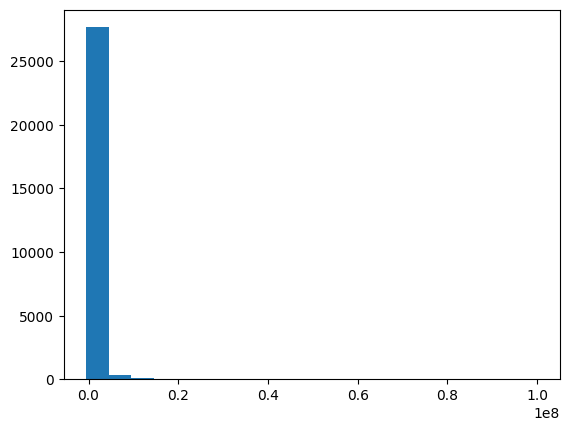

In [7]:
df['Foreign Gift Amount'].hist(bins=20, grid=False)

In [8]:
df['Foreign Gift Amount'].describe()

,Foreign Gift Amount
count,2.822100e+04
mean,5.882327e+05
std,3.222011e+06
min,-5.377700e+05
25%,5.700000e+03
50%,9.461500e+04
75%,3.761420e+05
max,1.000000e+08


Q2,2

The foreign Gift Amount variable appears mostly right-skewed. A small number of very large gifts create a long right tail, while most of the gifts are on the lower end. The median gift amount was around $94615, while the mean is about $588,233 which is way higher. The largest gift was $100 million and the lowest was -$537,700.

Q2.#3

In [9]:
df['Gift Type'].value_counts()

,count
Gift Type,
Contract,17274
Monetary Gift,10936
Real Estate,11


In [10]:
df['Gift Type'].value_counts(normalize=True)

,proportion
Gift Type,
Contract,0.612097
Monetary Gift,0.387513
Real Estate,0.000390


Q2.3
Contracts make up the largest proportion of foreign gifts about 61.21% , next was the monetary gifts at about 38.75%. Real estate gifts were the most rare making about 0.04% of the gifts.

In [12]:
df['log_gift'] = np.nan

df.loc[df['Foreign Gift Amount'] > 0, 'log_gift'] = np.log(
    df.loc[df['Foreign Gift Amount'] > 0, 'Foreign Gift Amount']
)

<Axes: ylabel='Density'>

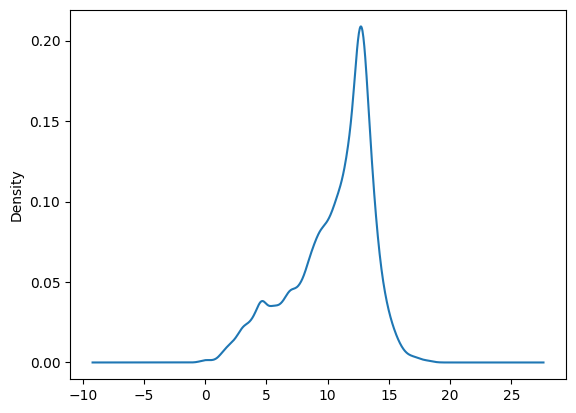

In [13]:
df['log_gift'].plot.density()

,log_gift
Gift Type,
Contract,"Axes(0.125,0.11;0.775x0.77)"
Monetary Gift,"Axes(0.125,0.11;0.775x0.77)"
Real Estate,"Axes(0.125,0.11;0.775x0.77)"


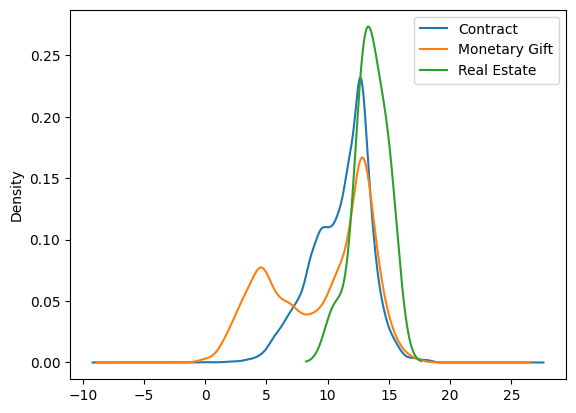

In [14]:
df.groupby('Gift Type')['log_gift'].plot.density(legend=True)

Q2, 4
After taking the log of Foreign Gift Amount, the distribution is less skewed. When comparing the gift types, contracts are mostly concentrated at higher gift amounts, while monetary gifts are more spread out and include more smaller amounts. Real estate gifts also appear to be concentrated at higher amounts, but there are only 11 real estate gifts, so this pattern should be interpreted sparingly.

In [15]:
df.groupby('Country of Giftor')['Foreign Gift Amount'].count().sort_values(ascending=False).head(15)

,Foreign Gift Amount
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
SAUDI ARABIA,1610
FRANCE,1437
GERMANY,1394
HONG KONG,1080


In [16]:
df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)

,Foreign Gift Amount
Country of Giftor,
QATAR,2706240869
ENGLAND,1464906771
CHINA,1237952112
SAUDI ARABIA,1065205930
BERMUDA,899593972
CANADA,898160656
HONG KONG,887402529
JAPAN,655954776
SWITZERLAND,619899445


England had the highest number of gifts with 3,655, next is China with 2,461 and Canada with 2,344. However, Qatar gave the largest total amount with about $2.72 billion. Following qatar is England at $1.46 billion and china at $1.24 billion.

Q2 , #6

In [17]:
df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)

,Foreign Gift Amount
Giftor Name,
Qatar Foundation,1166503744
Qatar Foundation/Qatar National Res,796197000
Qatar Foundation for Education,373945215
Anonymous,338793629
Saudi Arabian Cultural Mission,275221475
HCL,190000000
Church of Jesus Christ of LDS,185203715
Emirates Institute for Advanced Sc,170641244
QIC,148355497


Q2, 6
With approximately $1.17 billion, Qatar Foundation providedteh most money in total. It was followed by Qatar National Res at approximately $796 million and Qatar Foundation for Education at approximately $374 million. Overall, Qatar-related organizations appear several times among the largest giftors.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [2]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]